# Прогнозирование длительности поездок на такси в Нью-Йорке

## Анализ датасета

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/МОиНС/NYC.csv')
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


### Описание признаков

- **id** - уникальный идентификатор поездки
- **vendor_id** - идентификатор компании-партнера, предоставившей данные
- **pickup_datetime** - дата и время, когда включили счетчик (начало поездки)
- **dropoff_datetime** - дата и время, когда выключили счетчик (конец поездки)
- **passenger_count** - количество пассажиров в такси
- **pickup_longitude** - долгота места посадки
- **pickup_latitude** - широта места посадки
- **dropoff_longitude** - долгота места высадки
- **dropoff_latitude** - широта места высадки
- **store_and_fwd_flag** - флаг: хранились ли данные на борту такси перед отправкой в сервер (Y = да, N = нет, пустое значение)
- **trip_duration** - длительность поездки в секундах (ЦЕЛЕВАЯ ПЕРЕМЕННАЯ)

In [3]:
df.shape

(1458644, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [5]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


Сразу можем заметить, что не все признаки являются числовыми. Их нужно будет обработать.

In [6]:
df.isnull().sum()

,0
id,0
vendor_id,0
pickup_datetime,0
dropoff_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0


Пропущенных значений нет.


In [7]:
df.nunique()

,0
id,1458644
vendor_id,2
pickup_datetime,1380222
dropoff_datetime,1380377
passenger_count,10
pickup_longitude,23047
pickup_latitude,45245
dropoff_longitude,33821
dropoff_latitude,62519
store_and_fwd_flag,2


In [8]:
df.passenger_count.value_counts()

,count
passenger_count,
1,1033540
2,210318
5,78088
3,59896
6,48333
4,28404
0,60
7,3
9,1


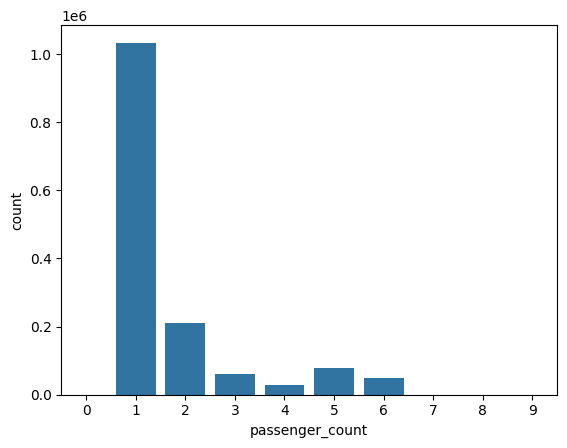

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=df.passenger_count)
plt.show()

Заметим, что в основном люди ездят в такси по одному.

Зафиксированы случаи с 0 пассажиров. Возможно, перевозили посылку

Также есть поездки с очень большим количеством пассажиров (7, 8, 9). Возможно, такси было не ообычным, а, к примеру, минивен.

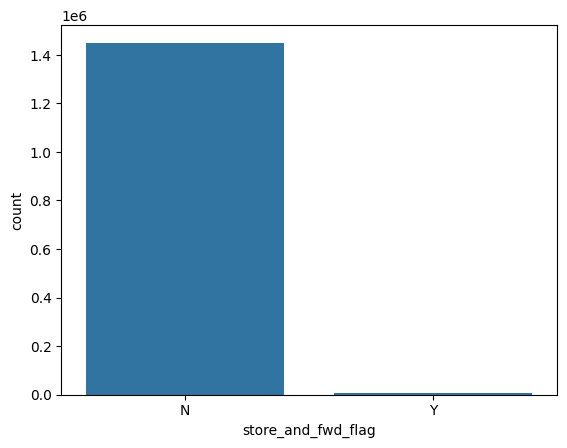

In [10]:
sns.countplot(x=df.store_and_fwd_flag)
plt.show()

Практически всегда данные о поездке сразу отправляются на сервер и не требует хранения на борту такси.

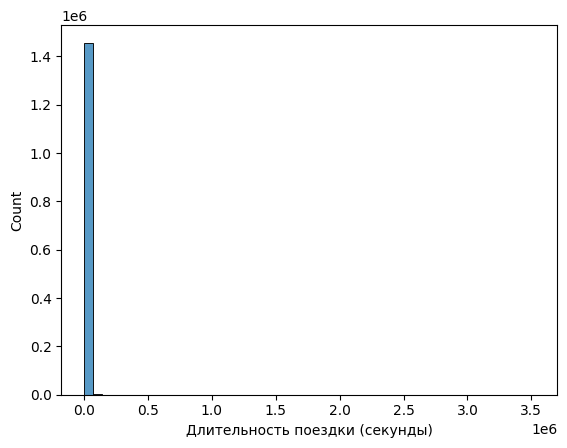

In [11]:
sns.histplot(x=df.trip_duration, bins=50)
plt.xlabel('Длительность поездки (секунды)')
plt.show()

Явно есть выбросы, поэтому по такому графику сложно что-то понять. Выбросы я обработаю чуть позже, а сейчас посмотрим на логарифмическую шкалу:

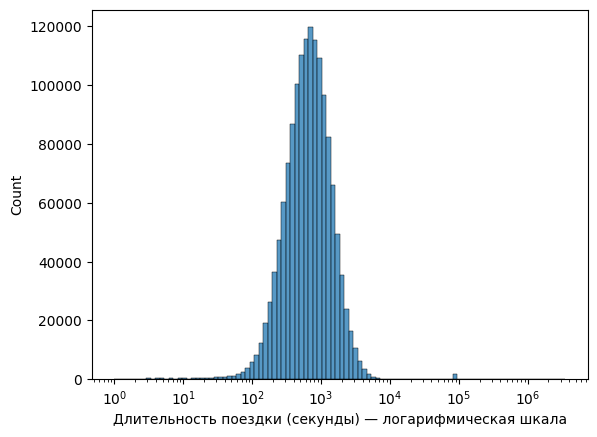

In [12]:
sns.histplot(x=df.trip_duration, bins=100, log_scale=True)
plt.xlabel('Длительность поездки (секунды) — логарифмическая шкала')
plt.show()

Теперь можем заметить, что большинство поездок: 15 - 16 минут. Количество более коротких и более длинных поездок убывают.

## Предобработка данных

Сразу удаляем уникальный идентификатор, так как для обучения он не нужен

In [13]:
df = df.drop(columns=['id'])

### Созадние новых признаков

#### Начнем с обработки даты и времени

In [14]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month

df.sample()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day_of_week,month
187951,2,2016-02-08 17:03:51,2016-02-08 17:25:56,1,-73.987061,40.755421,-73.861847,40.768509,N,1325,17,0,2


In [15]:
df['month'].unique()

array([3, 6, 1, 4, 5, 2], dtype=int32)

Данные охватывают январь–июнь 2016 года

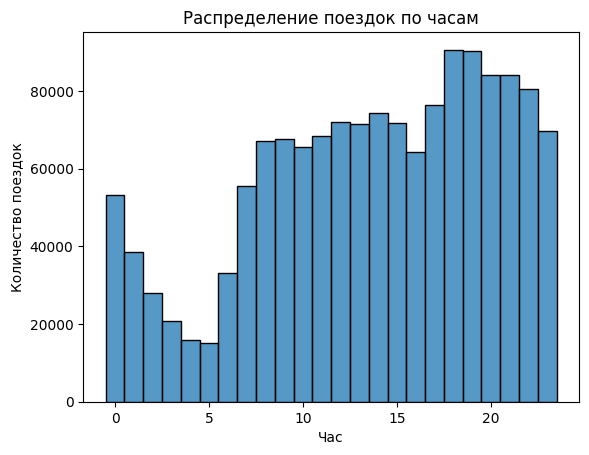

In [16]:
sns.histplot(x=df['hour'], bins=24, discrete=True)
plt.title('Распределение поездок по часам')
plt.xlabel('Час')
plt.ylabel('Количество поездок')
plt.show()

Час пик около 18:00-19:00.
Меньше всего поездок с 01:00 до 06:00.

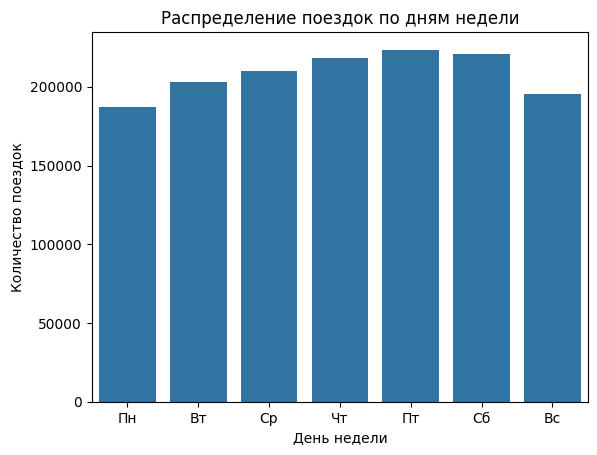

In [17]:
days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
sns.countplot(x=df['day_of_week'], order=range(7))
plt.title('Распределение поездок по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.xticks(range(7), days)
plt.show()

По дням поездки распределены примерно одинаково.

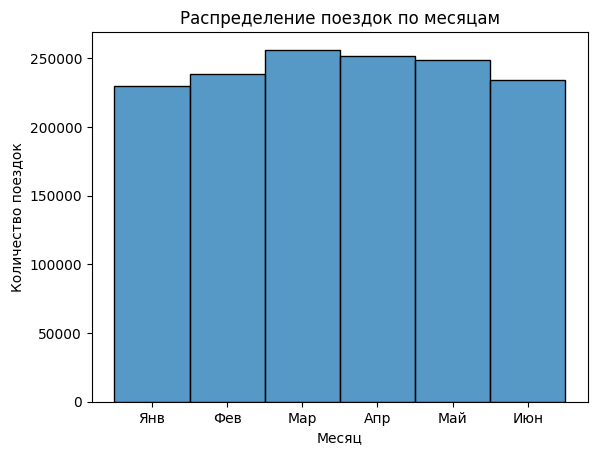

In [18]:
month = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн']  # полные названия
sns.histplot(x=df['month'], bins=6, discrete=True)
plt.title('Распределение поездок по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество поездок')
plt.xticks(ticks=range(1, 7), labels=month)
plt.show()

По месяцам распределение тоже примерно одинаковое.

Теперь у нас есть признаки:
- **hour** - час посадки
- **day_of_week** - день недели посадки
- **month** - месяц посадки

Но эти признаки необходимо обработать, так как модель не понимает, что, к примеру, 23 часа и 0 часов находятся рядом. Для нее 23 гораздо больше 0.

Воспользуемся циклическим кодированием для hour и day_of_week. Не будем обрабатывать month, так как у нас всего 6 месяцев.

In [19]:
import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

Теперь удалим лишние признаки, связанные с датой:

In [20]:
df = df.drop(columns=['pickup_datetime',	'dropoff_datetime', 'hour', 'day_of_week'])
df.sample()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,month,hour_sin,hour_cos,dow_sin,dow_cos
1432407,1,1,-74.003654,40.726452,-73.984711,40.742081,N,776,2,-1.0,-1.836970e-16,0.974928,-0.222521


Теперь моделям будет проще понять эти признаки.

#### Заменим широту и долготу на расстояние между точками посадки и высадки.

In [21]:
def haversine_distance(lon1, lat1, lon2, lat2):
    """Расстояние между двумя точками на Земле в километрах"""
    # Переводим градусы в радианы
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Формула Гаверсина
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    # Радиус Земли = 6371 км
    return 6371 * c

In [22]:
df['distance_km'] = haversine_distance(df['pickup_longitude'], df['pickup_latitude'], df['dropoff_longitude'], df['dropoff_latitude'])
df.sample()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,month,hour_sin,hour_cos,dow_sin,dow_cos,distance_km
539136,1,2,-73.95546,40.768555,-73.985268,40.768757,N,879,6,-0.707107,-0.707107,-0.974928,-0.222521,2.510348


Теперь можем удалить ненужные признаки:

In [23]:
df = df.drop(columns=['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude'])
df.sample()

,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,month,hour_sin,hour_cos,dow_sin,dow_cos,distance_km
964249,2,1,N,257,5,0.707107,-0.707107,-0.974928,-0.222521,1.054197


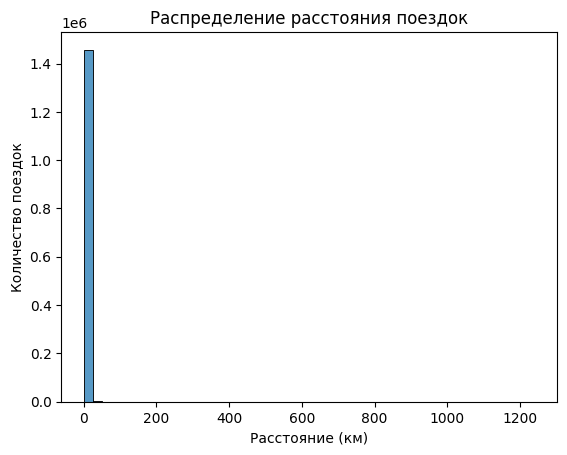

In [24]:
sns.histplot(x=df['distance_km'], bins=50)
plt.title('Распределение расстояния поездок')
plt.xlabel('Расстояние (км)')
plt.ylabel('Количество поездок')
plt.show()

По такому графику ничего не понятно. Посмотрим на логарифмическую шкалу:

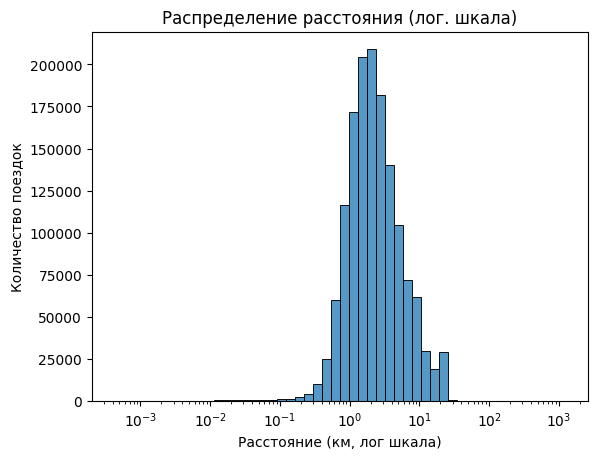

In [25]:
sns.histplot(x=df['distance_km'], bins=50, log_scale=True)
plt.title('Распределение расстояния (лог. шкала)')
plt.xlabel('Расстояние (км, лог шкала)')
plt.ylabel('Количество поездок')
plt.show()

Наибольшее количество поездок: ~5км.

### Кодирование категориальных признаков

In [26]:
# Y=1, N=0
df['store_and_fwd_flag'] = (df['store_and_fwd_flag'] == 'Y').astype(int)

In [27]:
df.sample()

,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,month,hour_sin,hour_cos,dow_sin,dow_cos,distance_km
524403,2,1,0,1157,2,0.258819,-0.965926,-0.433884,-0.900969,2.232501


### Обработка выбросов

#### Удалим явные ошибки в данных:
1) Время поездки < минуты, а расстояние > 10км

In [28]:
short_trips = df[(df['trip_duration'] < 60) & (df['distance_km'] > 10)]
print(short_trips[['distance_km', 'trip_duration']])

         distance_km  trip_duration
906281     19.948152             51
1176337    18.034405              7


In [29]:
df = df[~((df['trip_duration'] < 60) & (df['distance_km'] > 10))]

2) Время поездки > 2 часов, а расстояние < 1км

In [30]:
long_trips = df[(df['trip_duration'] > 7200) & (df['distance_km'] < 1)]
print(long_trips[['distance_km', 'trip_duration']])

         distance_km  trip_duration
4336        0.767894          83016
6513        0.670275          86357
10146       0.750437          86210
17996       0.923052          84616
24450       0.836270          82972
...              ...            ...
1436716     0.668240          86236
1451365     0.615820          86321
1455042     0.043148          11513
1457207     0.725878          85311
1458076     0.749437          86262

[328 rows x 2 columns]


In [31]:
df = df[~((df['trip_duration'] > 7200) & (df['distance_km'] < 1))]

3) Расстояние почти 0, но время большое (> 1 часа)

In [32]:
short_distance = df[(df['distance_km'] < 0.01) & (df['trip_duration'] > 3600)]
print(short_distance[['distance_km', 'trip_duration']])

         distance_km  trip_duration
14937       0.000000           3862
149352      0.000000           4683
451401      0.000000           4285
457033      0.000000           4579
471238      0.006185           4384
607368      0.000000           5929
674657      0.000000           4217
777678      0.006648           6499
796718      0.000000           3648
819760      0.000000           4578
848647      0.000000           4280
1128312     0.000000           3733
1211106     0.000000           4332
1245378     0.000000           4247
1268052     0.007662           3890
1274384     0.000000           4207
1330943     0.009756           3689
1355568     0.000000           3703


In [33]:
df = df[~((df['distance_km'] < 0.01) & (df['trip_duration'] > 3600))]

In [34]:
df.shape

(1458296, 10)

Таким убразом мы удалили 348 явных ошибок в данных.

#### Посмотрим на матрицу корреляции

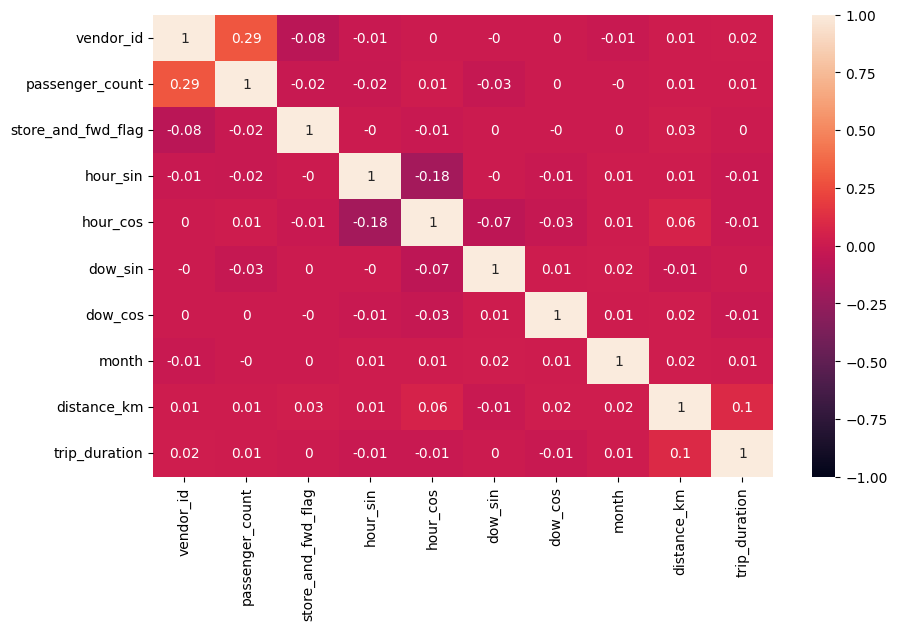

In [35]:
cm = df[['vendor_id', 'passenger_count', 'store_and_fwd_flag', 'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos', 'month', 'distance_km', 'trip_duration']].corr().round(2)

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, vmin=-1, vmax=1)
plt.show()

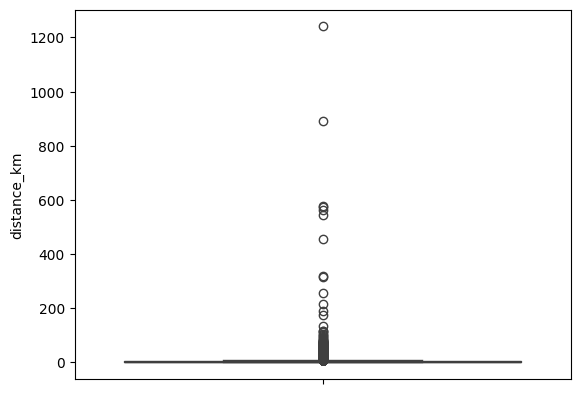

In [36]:
sns.boxplot(data=df.distance_km)
plt.show()

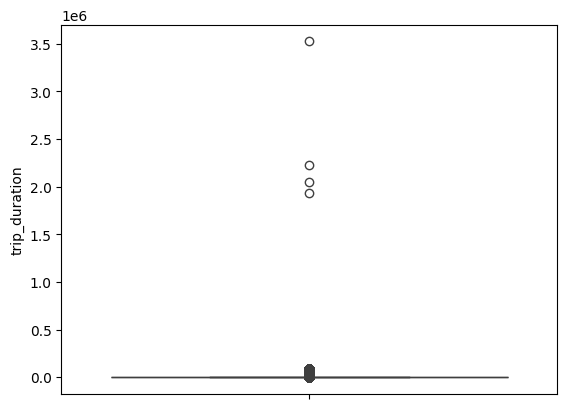

In [37]:
sns.boxplot(data=df.trip_duration)
plt.show()

Огромные выбросы все равно остались. Разделим данные на тренировочные и тестовые, а затем определим границы для обрезания данных.

#### Разделим данные на тренировочные и тестовые:

In [38]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['trip_duration'])
y = df['trip_duration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

#### Определяем границы только по train

In [39]:
duration_upper = y_train.quantile(0.99)
duration_lower = y_train.quantile(0.01)

distance_upper = X_train['distance_km'].quantile(0.99)
distance_lower = X_train['distance_km'].quantile(0.01)

print(f"Длительность: {duration_lower:.1f} - {duration_upper:.1f} сек")
print(f"Расстояние: {distance_lower:.2f} - {distance_upper:.2f} км")

Длительность: 87.0 - 3417.6 сек
Расстояние: 0.14 - 20.79 км


#### Применяем фильтрацию к train

In [40]:
train_mask = (
    (y_train >= duration_lower) & (y_train <= duration_upper) &
    (X_train['distance_km'] >= distance_lower) & (X_train['distance_km'] <= distance_upper)
)

X_train = X_train[train_mask]
y_train = y_train[train_mask]

print(f"Train после фильтрации: {X_train.shape}")

Train после фильтрации: (1129029, 9)


#### Применяем такую же фильтрацию к test

In [41]:
test_mask = (
    (y_test >= duration_lower) & (y_test <= duration_upper) &
    (X_test['distance_km'] >= distance_lower) & (X_test['distance_km'] <= distance_upper)
)

X_test = X_test[test_mask]
y_test = y_test[test_mask]

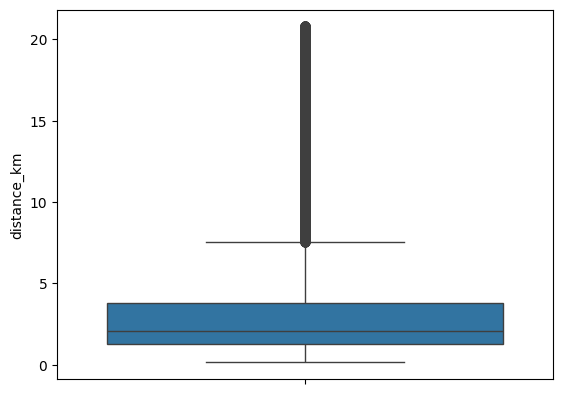

In [42]:
sns.boxplot(data=X_train.distance_km)
plt.show()

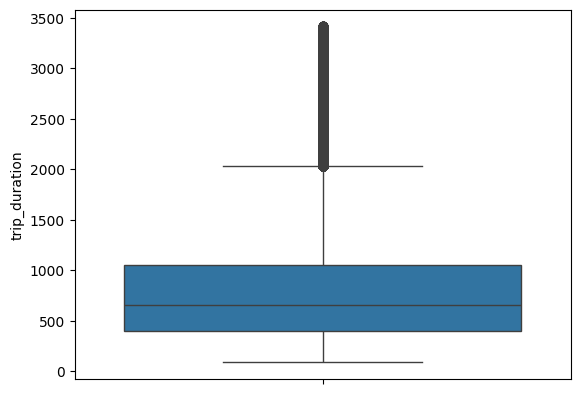

In [43]:
sns.boxplot(data=y_train)
plt.show()

Теперь графики выглядит горздо лучше.

#### Посмотрим на матрицу корреляции после обработки выбросов на тренировочных данных:

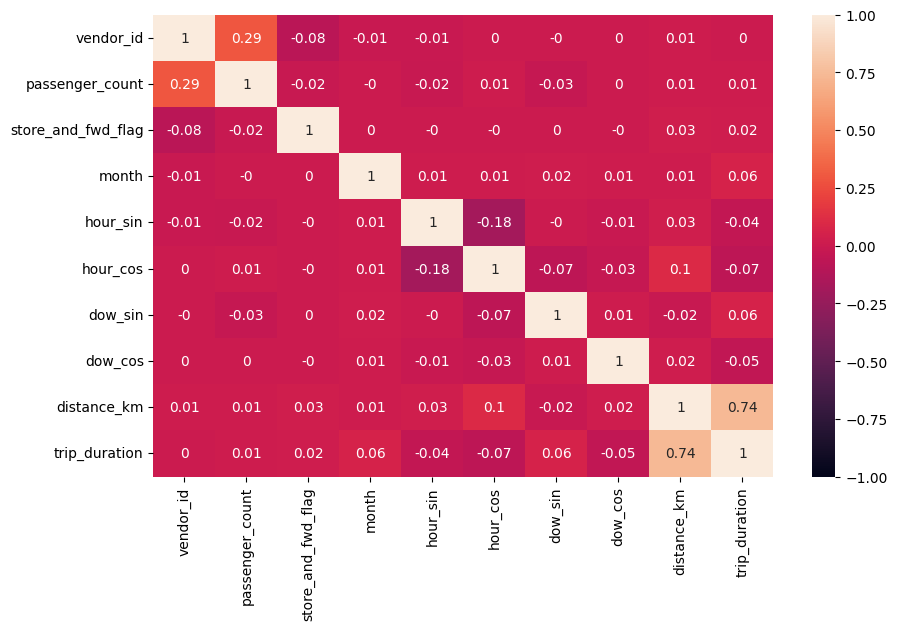

In [44]:
train_clean = X_train.copy()
train_clean['trip_duration'] = y_train

plt.figure(figsize=(10, 6))
corr_matrix = train_clean.corr().round(2)
sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1)
plt.show()

Вот теперь явно заметна линейная связь между расстоянием и временем. Часы, дни и месяцы пока что не влияют на целевую переменную, так как sin и cos должны рассматриваться вместе. Модели должны уловить этот момент.

### Масштабирование признаков

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Создание моделей

### 1) Линейная регрессия

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print(f"MSE: {mean_squared_error(y_test, y_pred_lr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"R2: {r2_score(y_test, y_pred_lr):.4f}")

MSE: 125290.21
RMSE: 353.96
MAE: 256.51
R2: 0.5916


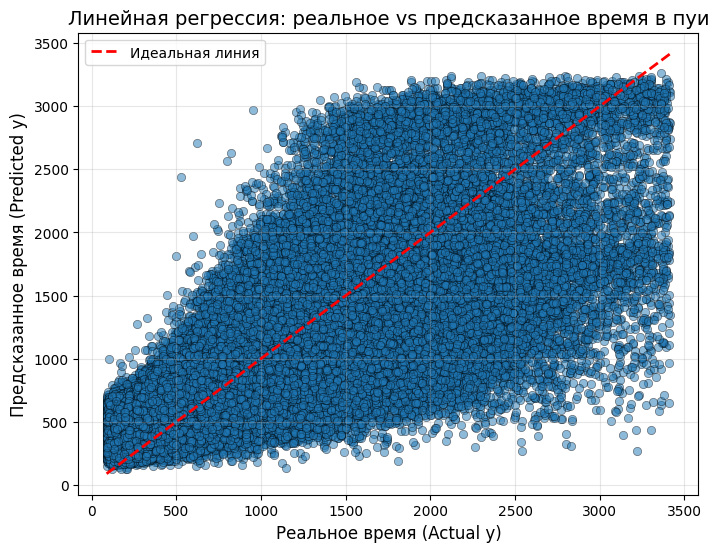

In [47]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.grid(True, alpha=0.3)
plt.xlabel('Реальное время (Actual y)', fontsize=12)
plt.ylabel('Предсказанное время (Predicted y)', fontsize=12)
plt.title('Линейная регрессия: реальное vs предсказанное время в пуи', fontsize=14)
plt.legend()
plt.show()

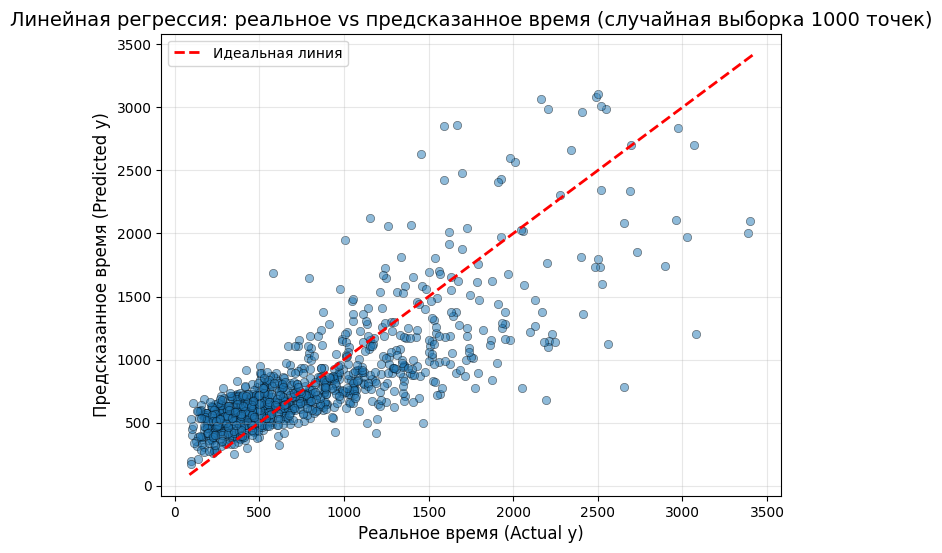

In [48]:
sample_size = 1000
indices = np.random.choice(len(y_test), size=sample_size, replace=False)

y_test_sample = y_test.iloc[indices] if hasattr(y_test, 'iloc') else y_test[indices]
y_pred_sample_lr = y_pred_lr[indices]

plt.figure(figsize=(8, 6))
plt.scatter(y_test_sample, y_pred_sample_lr, alpha=0.5, edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.grid(True, alpha=0.3)
plt.xlabel('Реальное время (Actual y)', fontsize=12)
plt.ylabel('Предсказанное время (Predicted y)', fontsize=12)
plt.title('Линейная регрессия: реальное vs предсказанное время (случайная выборка 1000 точек)', fontsize=14)
plt.legend(loc='upper left')
plt.show()

#### Вывод по линейной регрессии

Модель показала R² = 0.59, MAE = 257 секунд (~4.3 минуты). Это приемлемый базовый уровень, но невысокий R² говорит о том, что линейная модель плохо улавливает сложные зависимости. Будем использовать как точку отсчёта для сравнения с другими моделями.

### 2) Случайный лес (Random Forest)

In [49]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=50, max_depth=7, min_samples_split=5, random_state=0)
rfr.fit(X_train, y_train)
y_pred_rfr = rfr.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred_rfr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rfr)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rfr):.2f}")
print(f"R2: {r2_score(y_test, y_pred_rfr):.4f}")

MSE: 97511.32
RMSE: 312.27
MAE: 220.85
R2: 0.6822


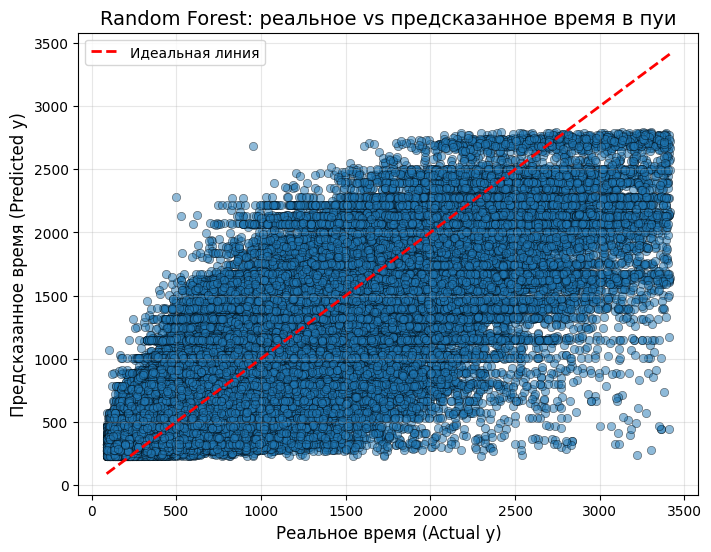

In [50]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rfr, alpha=0.5, edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.grid(True, alpha=0.3)
plt.xlabel('Реальное время (Actual y)', fontsize=12)
plt.ylabel('Предсказанное время (Predicted y)', fontsize=12)
plt.title('Random Forest: реальное vs предсказанное время в пуи', fontsize=14)
plt.legend(loc='upper left')
plt.show()

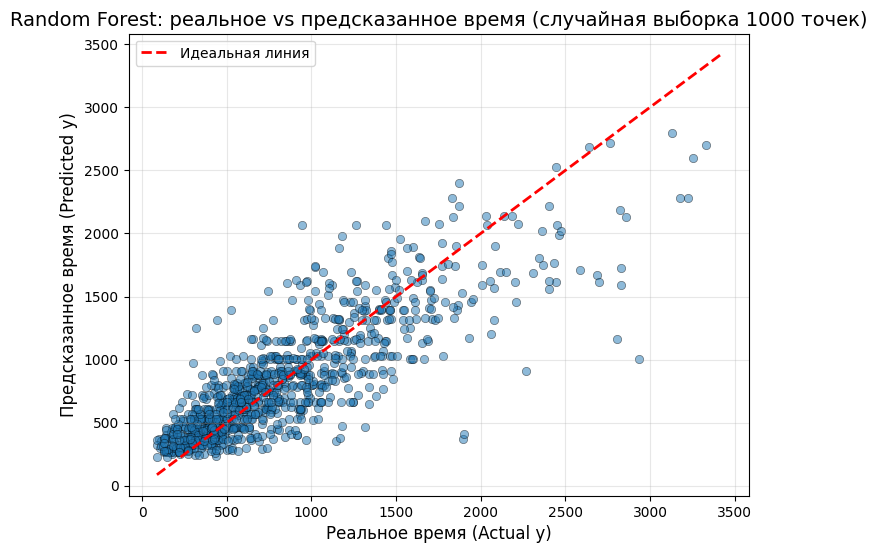

In [51]:
sample_size = 1000
indices = np.random.choice(len(y_test), size=sample_size, replace=False)

y_test_sample = y_test.iloc[indices] if hasattr(y_test, 'iloc') else y_test[indices]
y_pred_sample_rfr = y_pred_rfr[indices]

plt.figure(figsize=(8, 6))
plt.scatter(y_test_sample, y_pred_sample_rfr, alpha=0.5, edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.grid(True, alpha=0.3)
plt.xlabel('Реальное время (Actual y)', fontsize=12)
plt.ylabel('Предсказанное время (Predicted y)', fontsize=12)
plt.title('Random Forest: реальное vs предсказанное время (случайная выборка 1000 точек)', fontsize=14)
plt.legend(loc='upper left')
plt.show()

#### Подбор гиперпараметров для Random Forest

In [52]:
from sklearn.model_selection import RandomizedSearchCV

param_rand_rfr = {
    'n_estimators': [50, 100],
    'max_depth': [7, 10, 15],
    'min_samples_split': [5, 10],
}

rfr_gs = RandomForestRegressor(random_state=0)

random_search_rfr = RandomizedSearchCV(rfr_gs, param_rand_rfr, n_iter=10, cv=2, scoring='r2', random_state=0, verbose=2)
random_search_rfr.fit(X_train, y_train)

print("Лучшие параметры:", random_search_rfr.best_params_)
print("Лучший R2 на кросс-валидации:", random_search_rfr.best_score_)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
[CV] END max_depth=10, min_samples_split=10, n_estimators=50; total time= 1.8min
[CV] END max_depth=10, min_samples_split=10, n_estimators=50; total time= 1.8min
[CV] END max_depth=15, min_samples_split=10, n_estimators=100; total time= 4.7min
[CV] END max_depth=15, min_samples_split=10, n_estimators=100; total time= 4.7min
[CV] END .max_depth=10, min_samples_split=5, n_estimators=50; total time= 1.8min
[CV] END .max_depth=10, min_samples_split=5, n_estimators=50; total time= 1.8min
[CV] END max_depth=15, min_samples_split=10, n_estimators=50; total time= 2.4min
[CV] END max_depth=15, min_samples_split=10, n_estimators=50; total time= 2.4min
[CV] END .max_depth=7, min_samples_split=10, n_estimators=50; total time= 1.4min
[CV] END .max_depth=7, min_samples_split=10, n_estimators=50; total time= 1.4min
[CV] END .max_depth=15, min_samples_split=5, n_estimators=50; total time= 2.4min
[CV] END .max_depth=15, min_samples_split=5, n

In [53]:
best_rfr = random_search_rfr.best_estimator_
y_pred_best_rfr = best_rfr.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred_best_rfr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best_rfr)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_best_rfr):.2f}")
print(f"R2: {r2_score(y_test, y_pred_best_rfr):.4f}")

MSE: 93259.91
RMSE: 305.38
MAE: 215.39
R2: 0.6960


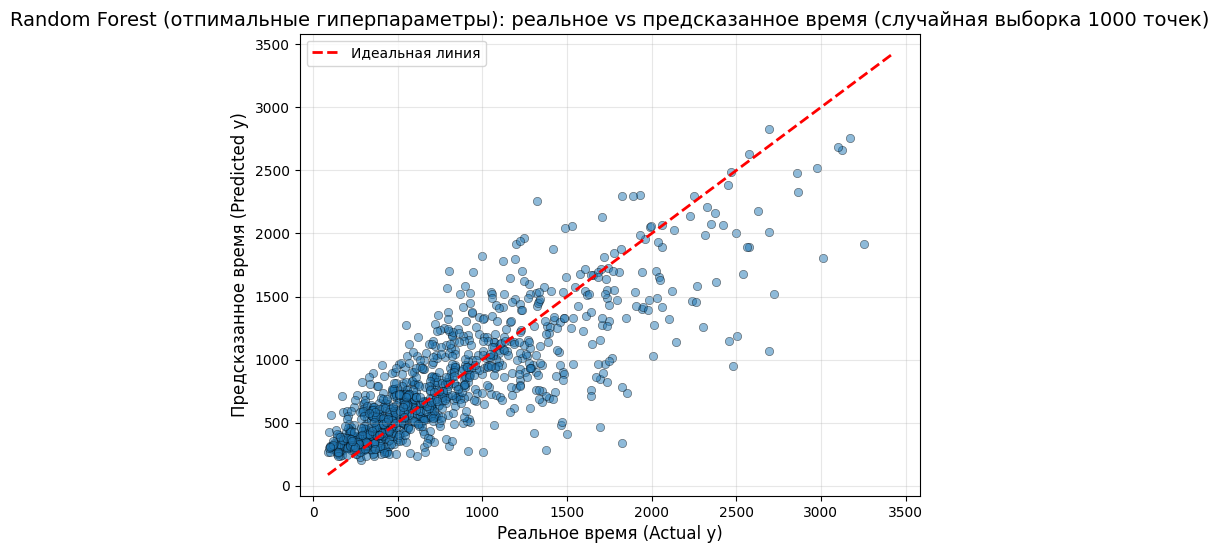

In [54]:
sample_size = 1000
indices = np.random.choice(len(y_test), size=sample_size, replace=False)

y_test_sample = y_test.iloc[indices] if hasattr(y_test, 'iloc') else y_test[indices]
y_pred_sample_rfr_rs = y_pred_best_rfr[indices]

plt.figure(figsize=(8, 6))
plt.scatter(y_test_sample, y_pred_sample_rfr_rs, alpha=0.5, edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.grid(True, alpha=0.3)
plt.xlabel('Реальное время (Actual y)', fontsize=12)
plt.ylabel('Предсказанное время (Predicted y)', fontsize=12)
plt.title('Random Forest (отпимальные гиперпараметры): реальное vs предсказанное время (случайная выборка 1000 точек)', fontsize=14)
plt.legend(loc='upper left')
plt.show()

#### Вывод по Random Forest

Модель показала R² = 0.70, MAE = 215 секунд (~3.6 минуты). Это заметно лучше линейной регрессии (R² = 0.59). Случайный лес смог уловить нелинейные зависимости (пробки, время суток), которые линейная модель пропустила.

### 3) Градиентный бустинг (Gradient Boosting)

In [55]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=50, max_depth=5, learning_rate=0.05, random_state=0)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred_gb):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_gb):.2f}")
print(f"R2: {r2_score(y_test, y_pred_gb):.4f}")

MSE: 97314.69
RMSE: 311.95
MAE: 222.73
R2: 0.6828


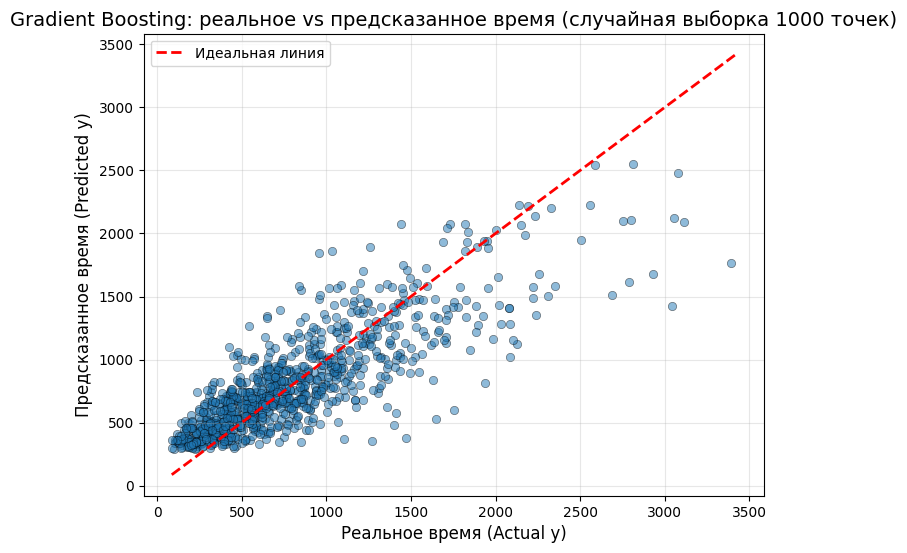

In [56]:
sample_size = 1000
indices = np.random.choice(len(y_test), size=sample_size, replace=False)

y_test_sample = y_test.iloc[indices] if hasattr(y_test, 'iloc') else y_test[indices]
y_pred_sample_gb = y_pred_gb[indices]

plt.figure(figsize=(8, 6))
plt.scatter(y_test_sample, y_pred_sample_gb, alpha=0.5, edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.grid(True, alpha=0.3)
plt.xlabel('Реальное время (Actual y)', fontsize=12)
plt.ylabel('Предсказанное время (Predicted y)', fontsize=12)
plt.title('Gradient Boosting: реальное vs предсказанное время (случайная выборка 1000 точек)', fontsize=14)
plt.legend(loc='upper left')
plt.show()

#### Подбор гиперпараметров для Gradient Boosting


In [57]:
from scipy.stats import randint, uniform

param_rand_gb = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 15),
    'learning_rate': uniform(0.01, 0.3),
    'min_samples_split': randint(2, 20),
    'subsample': uniform(0.6, 0.4)
}

gb_rs = GradientBoostingRegressor(random_state=0)

random_search_gb = RandomizedSearchCV(gb_rs, param_rand_gb, n_iter=8, cv=2, scoring='r2', random_state=0, verbose=2)
random_search_gb.fit(X_train, y_train)

print("Лучшие параметры:", random_search_gb.best_params_)
print("Лучший R2 на кросс-валидации:", random_search_gb.best_score_)

Fitting 2 folds for each of 8 candidates, totalling 16 fits
[CV] END learning_rate=0.17464405117819742, max_depth=8, min_samples_split=2, n_estimators=117, subsample=0.9431782470491027; total time= 5.7min
[CV] END learning_rate=0.17464405117819742, max_depth=8, min_samples_split=2, n_estimators=117, subsample=0.9431782470491027; total time= 5.6min
[CV] END learning_rate=0.2641755216352376, max_depth=6, min_samples_split=6, n_estimators=137, subsample=0.9567092003128319; total time= 5.1min
[CV] END learning_rate=0.2641755216352376, max_depth=6, min_samples_split=6, n_estimators=137, subsample=0.9567092003128319; total time= 5.1min
[CV] END learning_rate=0.2990988281503088, max_depth=13, min_samples_split=3, n_estimators=89, subsample=0.8115579679011617; total time= 5.8min
[CV] END learning_rate=0.2990988281503088, max_depth=13, min_samples_split=3, n_estimators=89, subsample=0.8115579679011617; total time= 5.8min
[CV] END learning_rate=0.1804133683281797, max_depth=8, min_samples_split=

In [58]:
best_gb = random_search_gb.best_estimator_
y_pred_best_gb = best_gb.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred_best_gb):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best_gb)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_best_gb):.2f}")
print(f"R2: {r2_score(y_test, y_pred_best_gb):.4f}")

MSE: 92075.40
RMSE: 303.44
MAE: 213.87
R2: 0.6999


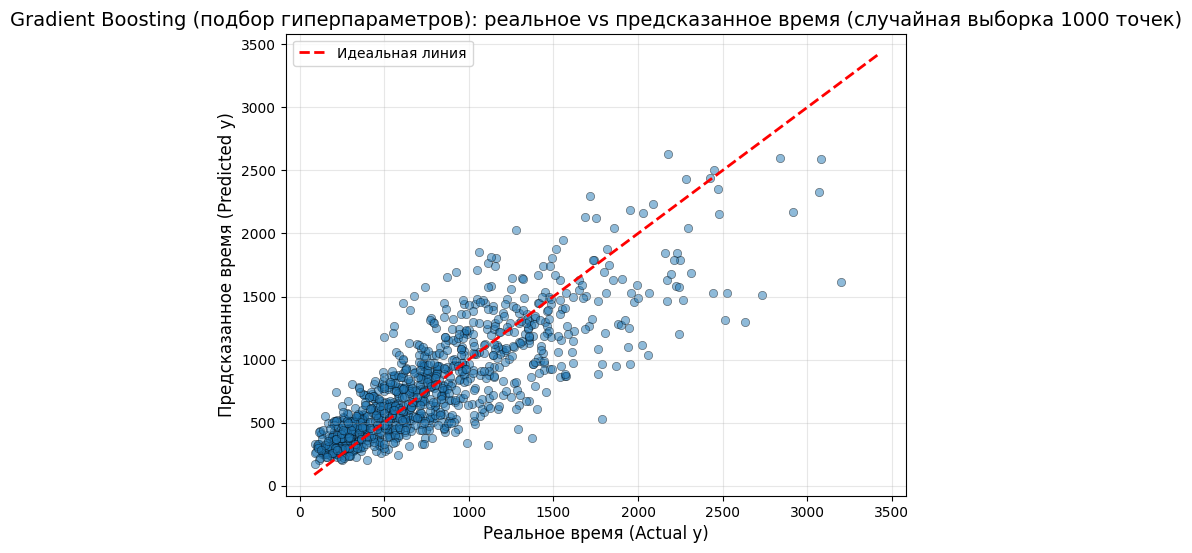

In [59]:
sample_size = 1000
indices = np.random.choice(len(y_test), size=sample_size, replace=False)

y_test_sample = y_test.iloc[indices] if hasattr(y_test, 'iloc') else y_test[indices]
y_pred_sample_gb_rs = y_pred_best_gb[indices]

plt.figure(figsize=(8, 6))
plt.scatter(y_test_sample, y_pred_sample_gb_rs, alpha=0.5, edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.grid(True, alpha=0.3)
plt.xlabel('Реальное время (Actual y)', fontsize=12)
plt.ylabel('Предсказанное время (Predicted y)', fontsize=12)
plt.title('Gradient Boosting (подбор гиперпараметров): реальное vs предсказанное время (случайная выборка 1000 точек)', fontsize=14)
plt.legend(loc='upper left')
plt.show()

#### Вывод по Gradient Boosting

Модель показала R² = 0.70, MAE = 214 секунд (~3.6 минуты). Результат практически идентичен Random Forest. Градиентный бустинг дал небольшое улучшение по сравнению со случайным лесом, но разница незначительная.

### 4) KNN (K ближайших соседей)

In [60]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

param_grid_knn = {
    'n_neighbors': [30, 40],
    'weights': ['distance'],
    'leaf_size': [20, 30],
    'algorithm': ['auto']
}

knn = KNeighborsRegressor()

grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=2, scoring='r2', verbose=2)
grid_search_knn.fit(X_train_scaled, y_train)

print("Лучшие параметры:", grid_search_knn.best_params_)
print("Лучший R2 на кросс-валидации:", grid_search_knn.best_score_)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
[CV] END algorithm=auto, leaf_size=20, n_neighbors=30, weights=distance; total time= 3.7min
[CV] END algorithm=auto, leaf_size=20, n_neighbors=30, weights=distance; total time= 3.8min
[CV] END algorithm=auto, leaf_size=20, n_neighbors=40, weights=distance; total time= 4.2min
[CV] END algorithm=auto, leaf_size=20, n_neighbors=40, weights=distance; total time= 4.2min
[CV] END algorithm=auto, leaf_size=30, n_neighbors=30, weights=distance; total time= 3.7min
[CV] END algorithm=auto, leaf_size=30, n_neighbors=30, weights=distance; total time= 3.7min
[CV] END algorithm=auto, leaf_size=30, n_neighbors=40, weights=distance; total time= 4.3min
[CV] END algorithm=auto, leaf_size=30, n_neighbors=40, weights=distance; total time= 4.2min
Лучшие параметры: {'algorithm': 'auto', 'leaf_size': 20, 'n_neighbors': 40, 'weights': 'distance'}
Лучший R2 на кросс-валидации: 0.6508741398413503


In [61]:
best_knn = grid_search_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)

print(f"MSE: {mean_squared_error(y_test, y_pred_knn):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_knn)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_knn):.2f}")
print(f"R2: {r2_score(y_test, y_pred_knn):.4f}")

MSE: 107375.54
RMSE: 327.68
MAE: 231.55
R2: 0.6500


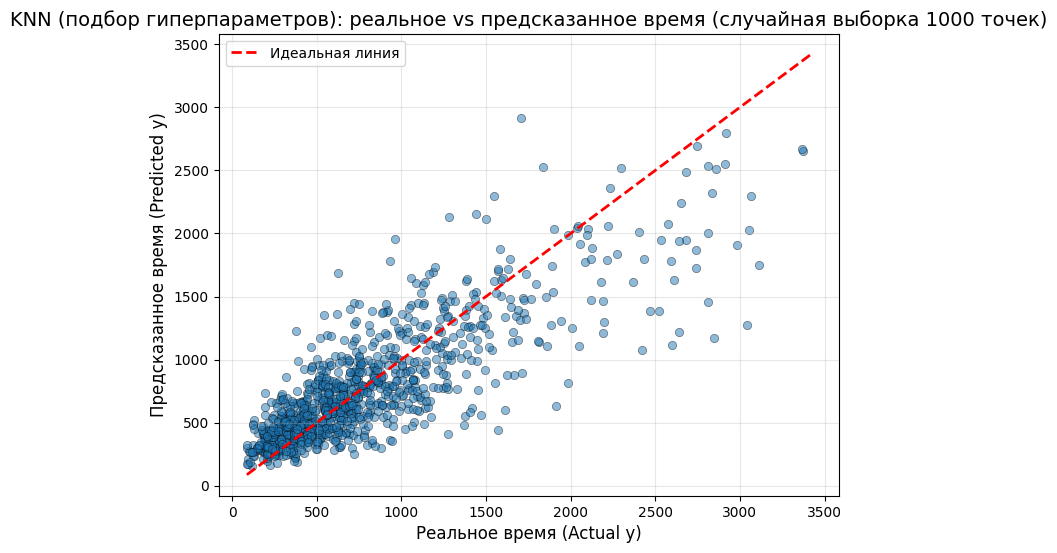

In [62]:
sample_size = 1000
indices = np.random.choice(len(y_test), size=sample_size, replace=False)

y_test_sample = y_test.iloc[indices] if hasattr(y_test, 'iloc') else y_test[indices]
y_pred_sample_knn = y_pred_knn[indices]

plt.figure(figsize=(8, 6))
plt.scatter(y_test_sample, y_pred_sample_knn, alpha=0.5, edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.grid(True, alpha=0.3)
plt.xlabel('Реальное время (Actual y)', fontsize=12)
plt.ylabel('Предсказанное время (Predicted y)', fontsize=12)
plt.title('KNN (подбор гиперпараметров): реальное vs предсказанное время (случайная выборка 1000 точек)', fontsize=14)
plt.legend(loc='upper left')
plt.show()

#### Вывод по KNN

Модель показала R² = 0.65, MAE = 232 секунды (~3.9 минуты). KNN уступил Random Forest и Gradient Boosting, что ожидаемо, так как метод ближайших соседей хуже справляется с большими объёмами данных и чувствителен к выбросам.

### 5) VotingRegressor (ансамбль моделей)

In [63]:
from sklearn.ensemble import VotingRegressor

voting = VotingRegressor([
    ('rf', best_rfr),
    ('gb', best_gb),
    #('knn', best_knn)
])

voting.fit(X_train, y_train)
y_pred_voting = voting.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred_voting):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_voting)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_voting):.2f}")
print(f"R2: {r2_score(y_test, y_pred_voting):.4f}")

MSE: 92241.29
RMSE: 303.71
MAE: 214.13
R2: 0.6993


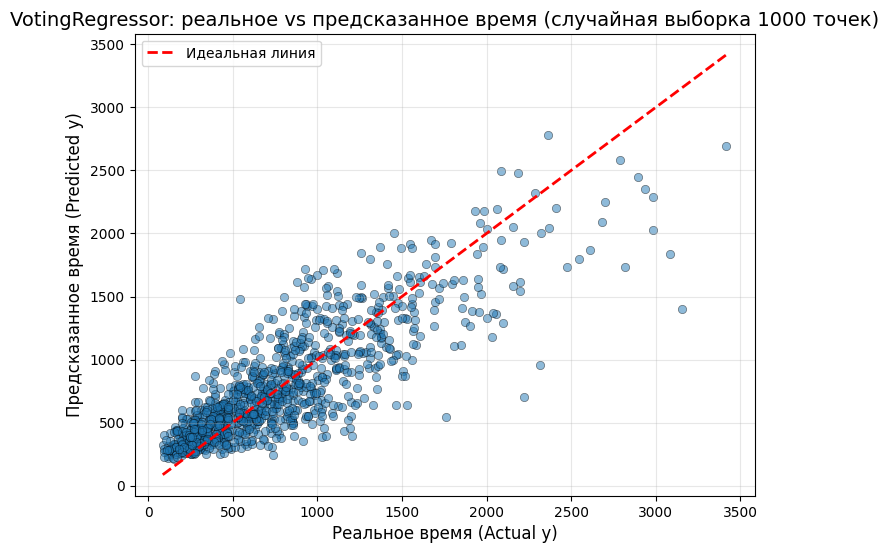

In [64]:
sample_size = 1000
indices = np.random.choice(len(y_test), size=sample_size, replace=False)

y_test_sample = y_test.iloc[indices] if hasattr(y_test, 'iloc') else y_test[indices]
y_pred_sample_voting = y_pred_voting[indices]

plt.figure(figsize=(8, 6))
plt.scatter(y_test_sample, y_pred_sample_voting, alpha=0.5, edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.grid(True, alpha=0.3)
plt.xlabel('Реальное время (Actual y)', fontsize=12)
plt.ylabel('Предсказанное время (Predicted y)', fontsize=12)
plt.title('VotingRegressor: реальное vs предсказанное время (случайная выборка 1000 точек)', fontsize=14)
plt.legend(loc='upper left')
plt.show()

#### Вывод по VotingRegressor

Ансамбль из трёх моделей показал R² = 0.70, MAE = 216 секунд (~3.6 минуты). Результат практически совпал с лучшими отдельными моделями (Random Forest и Gradient Boosting). Ансамбль не дал значительного улучшения, но и не ухудшил качество.

## Создание нейронной сети

### Первый вариант

In [65]:
from tensorflow import keras
from tensorflow.keras import Input

model = keras.Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=64, validation_split=0.2, callbacks=[early_stop], verbose=1)

Epoch 1/100
14113/14113 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - loss: 125803.3984 - mae: 250.9002 - val_loss: 99475.2734 - val_mae: 223.5349
Epoch 2/100
14113/14113 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - loss: 111903.3750 - mae: 237.5802 - val_loss: 97619.6328 - val_mae: 220.5511
Epoch 3/100
14113/14113 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - loss: 110508.4453 - mae: 235.6299 - val_loss: 97522.8906 - val_mae: 221.0634
Epoch 4/100
14113/14113 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - loss: 109282.3281 - mae: 234.2970 - val_loss: 96784.7031 - val_mae: 221.7615
Epoch 5/100
14113/14113 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - loss: 108190.3203 - mae: 233.0367 - val_loss: 96225.5469 - val_mae: 218.9739
Epoch 6/100
14113/14113 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - loss: 106902.6172 - mae: 231.8904 - val_loss: 95668.4844 - val_mae: 217.5165
Epoch 7/100
14113/14113 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - loss: 105303.9297 - mae: 229.7745 - val_loss: 95408.4062 - val_mae: 216.7659
Epoch 8/100
14113/14113 ━━━━━━━━━━━━━━━━━

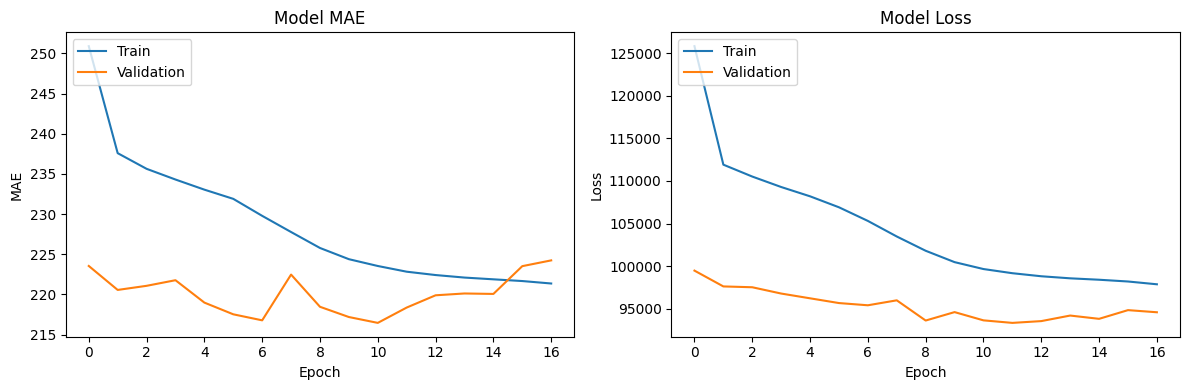

In [66]:
plt.figure(figsize=(12, 4))

# Первый график (точность)
plt.subplot(1, 2, 1)
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('Model MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Второй график (ошибка)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [67]:
y_pred_nn = model.predict(X_test_scaled).flatten()

print(f"MSE: {mean_squared_error(y_test, y_pred_nn):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_nn)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_nn):.2f}")
print(f"R2: {r2_score(y_test, y_pred_nn):.4f}")

8821/8821 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step
MSE: 94447.09
RMSE: 307.32
MAE: 219.32
R2: 0.6922


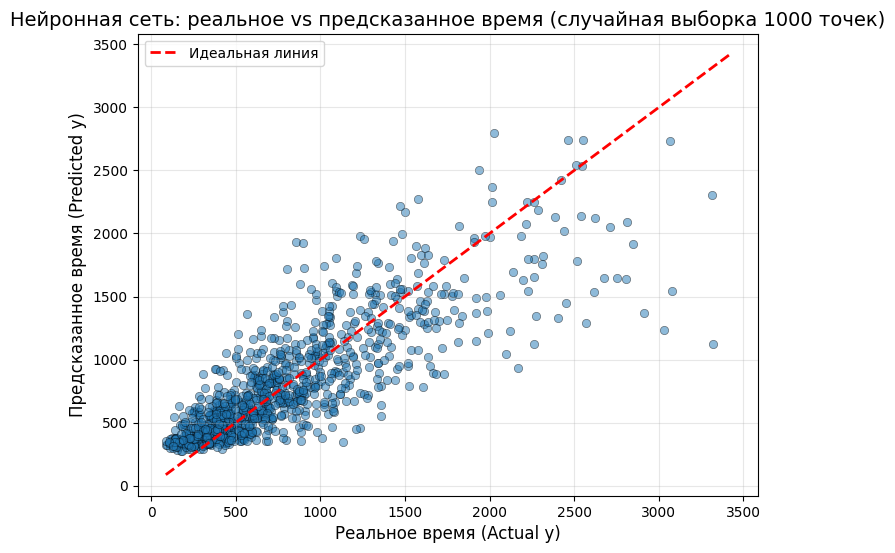

In [68]:
sample_size = 1000
indices = np.random.choice(len(y_test), size=sample_size, replace=False)

y_test_sample = y_test.iloc[indices] if hasattr(y_test, 'iloc') else y_test[indices]
y_pred_sample_nn = y_pred_nn[indices]

plt.figure(figsize=(8, 6))
plt.scatter(y_test_sample, y_pred_sample_nn, alpha=0.5, edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.grid(True, alpha=0.3)
plt.xlabel('Реальное время (Actual y)', fontsize=12)
plt.ylabel('Предсказанное время (Predicted y)', fontsize=12)
plt.title('Нейронная сеть: реальное vs предсказанное время (случайная выборка 1000 точек)', fontsize=14)
plt.legend(loc='upper left')
plt.show()

### Второй вариант
Сеть глубже и шире + добавил BatchNormalization для стабильности

In [69]:
from tensorflow import keras
from tensorflow.keras import Input

In [70]:
model2 = keras.Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.4),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.4),

    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(1)
])

model2.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop2 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history2 = model2.fit(X_train_scaled, y_train, epochs=100, batch_size=64, validation_split=0.2, callbacks=[early_stop2], verbose=1)

Epoch 1/100
14113/14113 ━━━━━━━━━━━━━━━━━━━━ 84s 6ms/step - loss: 134286.7188 - mae: 257.8687 - val_loss: 94197.0312 - val_mae: 216.7782
Epoch 2/100
14113/14113 ━━━━━━━━━━━━━━━━━━━━ 144s 6ms/step - loss: 121116.1797 - mae: 245.1829 - val_loss: 94180.2734 - val_mae: 214.4738
Epoch 3/100
14113/14113 ━━━━━━━━━━━━━━━━━━━━ 83s 6ms/step - loss: 118144.9219 - mae: 241.9394 - val_loss: 93544.5859 - val_mae: 213.6770
Epoch 4/100
14113/14113 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - loss: 115383.2891 - mae: 239.1341 - val_loss: 93501.9297 - val_mae: 212.8680
Epoch 5/100
14113/14113 ━━━━━━━━━━━━━━━━━━━━ 83s 6ms/step - loss: 113455.9062 - mae: 236.9257 - val_loss: 93041.2344 - val_mae: 212.9182
Epoch 6/100
14113/14113 ━━━━━━━━━━━━━━━━━━━━ 140s 6ms/step - loss: 112153.9531 - mae: 235.8882 - val_loss: 93976.6641 - val_mae: 214.2541
Epoch 7/100
14113/14113 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - loss: 111150.6562 - mae: 235.4001 - val_loss: 94564.1484 - val_mae: 213.8642
Epoch 8/100
14113/14113 ━━━━━━━━━━━━━━━

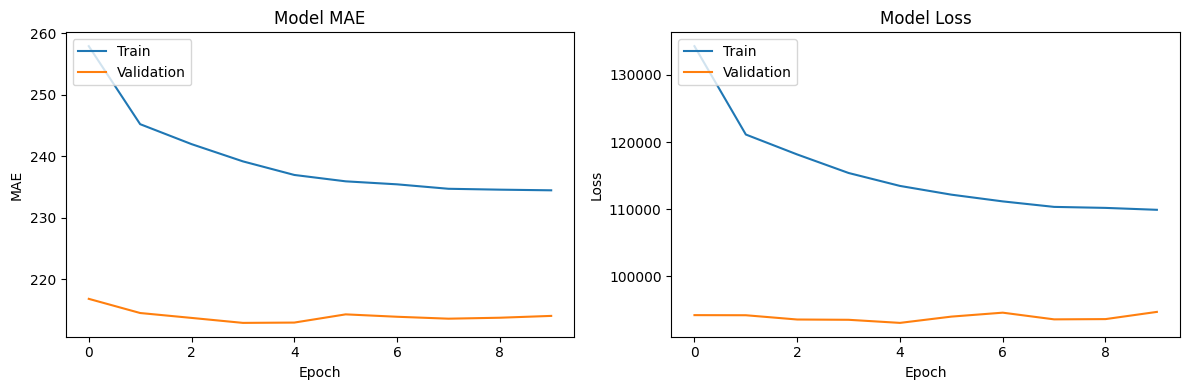

In [71]:
plt.figure(figsize=(12, 4))

# Первый график (точность)
plt.subplot(1, 2, 1)
plt.plot(history2.history['mae'])
plt.plot(history2.history['val_mae'])
plt.title('Model MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Второй график (ошибка)
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [72]:
y_pred_nn2 = model2.predict(X_test_scaled).flatten()

print(f"MSE: {mean_squared_error(y_test, y_pred_nn2):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_nn2)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_nn2):.2f}")
print(f"R2: {r2_score(y_test, y_pred_nn2):.4f}")

8821/8821 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step
MSE: 94147.69
RMSE: 306.83
MAE: 214.04
R2: 0.6931


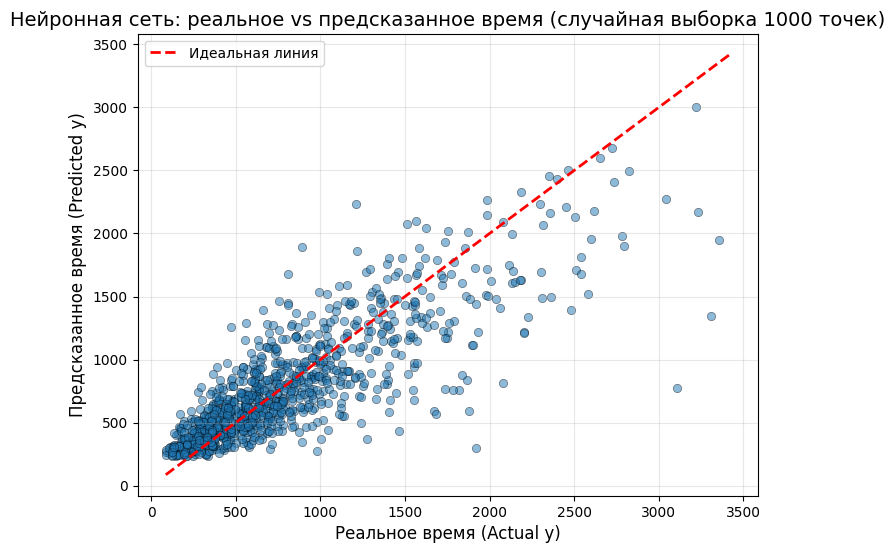

In [73]:
sample_size = 1000
indices = np.random.choice(len(y_test), size=sample_size, replace=False)

y_test_sample = y_test.iloc[indices] if hasattr(y_test, 'iloc') else y_test[indices]
y_pred_sample_nn2 = y_pred_nn2[indices]

plt.figure(figsize=(8, 6))
plt.scatter(y_test_sample, y_pred_sample_nn2, alpha=0.5, edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.grid(True, alpha=0.3)
plt.xlabel('Реальное время (Actual y)', fontsize=12)
plt.ylabel('Предсказанное время (Predicted y)', fontsize=12)
plt.title('Нейронная сеть: реальное vs предсказанное время (случайная выборка 1000 точек)', fontsize=14)
plt.legend(loc='upper left')
plt.show()

#### Вывод по нейронным сетям

Было обучено две архитектуры нейронных сетей: простая (128 - 64 - 32) и более глубокая с BatchNormalisation (256 - 128 - 64 - 32). Обе модели показали близкие результаты: R² ≈ 0.69, MAE ≈ 214-219 секунд (~3.5 минуты). Более сложная архитектура не дала существенного улучшения, что говорит о том, что для данного объёма данных простая сеть является достаточной. Нейросети показали результат, близкий к лучшим моделям (Random Forest и Gradient Boosting), что подтверждает их применимость для задачи. Однако деревья всё же остались лидерами, что характерно для табличных данных.

## Общий вывод

В ходе проекта было обучено 6 моделей для предсказания длительности поездки такси в Нью-Йорке.

1. **Лучший результат** показали Random Forest и Gradient Boosting (R² = 0.70, MAE ≈ 3.6 минуты). Деревья хорошо справились с нелинейными зависимостями.

2. **Линейная регрессия** ожидаемо оказалась слабее (R² = 0.59), так как не может уловить сложные паттерны в данных.

3. **Нейросеть** показала результат, близкий к деревьям (R² = 0.69), но не смогла их превзойти. Это типично для табличных данных среднего размера.

4. **KNN** уступил деревьям (R² = 0.65), так как метод ближайших соседей хуже справляется с большими объёмами данных и чувствителен к выбросам.

5. **Ансамбль (VotingRegressor)** не дал значительного улучшения по сравнению с лучшими отдельными моделями, что говорит о схожести их предсказаний.

### Итог

Лучшая модель предсказывает длительность поездки со средней ошибкой **~3.6 минуты**. Для реального применения этого достаточно, так как в условиях пробок и человеческого фактора точность до минуты недостижима. Рекомендуемая модель для использования — **Random Forest** как компромисс между качеством, скоростью обучения и интерпретируемостью.